# Predoc Data Task 3

Author: *Gavin Qu*
Date: April 25th, 2026

### A good operating model for leveraging AI
A strong default process is:

1. Prototype in a notebook or Quarto draft.

2. Ask Claude Code to extract stable logic into a script or module.

3. Add tests and a small CLAUDE.md that records project conventions.

4. Use Claude to refactor, document, and debug against explicit checks.

5. Produce final tables, figures, and writeup in Quarto or a publication-ready report.

### Practical plotting pattern
A practical pattern is:

1. Explore in a notebook or Quarto chunk.

2. Let Claude generate the first draft of the plot code.

3. Run it and inspect the result.

4. Ask Claude to clean up labels, scales, aesthetics, and edge cases.

5. Promote the final code into a function or reusable plotting helper.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pyfixest as pf

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style='whitegrid', palette='colorblind')

## Standardized Palette and Plot Helper

All figures below use `PAL` (single-color charts) or `PAL_CAT` (multi-category lines). `style_ax` applies recession shading, percent formatting, axis labels, and spine cleanup uniformly.


In [2]:
# Standardized palette + style helper (used across all plots)
import matplotlib.ticker as mticker

PAL = {
    'primary':   '#0127b2',   # dark blue  - single-series lines
    'accent':    '#DE8F05',   # gold       - highlighted bar, intensive-margin SS
    'highlight': '#b605de',   # purple     - treated / college cohort
    'control':   '#deba05',   # mustard    - control / non-college
    'cf':        '#ea241d',   # red        - DiD counterfactual line
    'shade':     '#ce4f4f',   # red shade  - DiD gap fill
    'neutral':   '#5A5A5A',   # gray       - annotations
}
PAL_CAT = sns.color_palette('colorblind', n_colors=6)
RECESSIONS = [(2007, 2009), (2020, 2020.5)]

def style_ax(ax, ylabel, title, percent=True, recessions=True, xlabel='Year'):
    if recessions:
        for s, e in RECESSIONS:
            ax.axvspan(s, e, alpha=0.12, color='gray', zorder=0)
    if percent:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)



## Data Ingestion and Loading



In [3]:
df = pd.read_csv("./data/cps_women_lfp.csv", low_memory=False)
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 6823494 entries, 0 to 6823493
Data columns (total 22 columns):
 #   Column               Dtype  
---  ------               -----  
 0   cpsidp               int64  
 1   wgt                  float64
 2   year                 int64  
 3   sex                  str    
 4   race                 str    
 5   education            str    
 6   college              str    
 7   age                  str    
 8   wageinc_quantiles    str    
 9   income_quantiles     str    
 10  inctot               float64
 11  incss                float64
 12  income               float64
 13  lfp                  str    
 14  employed             str    
 15  self_employed        str    
 16  covid_unemployed     str    
 17  covid_paid           str    
 18  covid_telework       str    
 19  telework_now         str    
 20  telework_before      str    
 21  telework_difference  str    
dtypes: float64(4), int64(2), str(16)
memory usage: 1.1 GB


,cpsidp,wgt,year,sex,race,education,college,age,wageinc_quantiles,income_quantiles,inctot,incss,income,lfp,employed,self_employed,covid_unemployed,covid_paid,covid_telework,telework_now,telework_before,telework_difference
0,19940100000101,2349.98,1994,Female,Black,< HS Diploma,No college degree,65-74,NaN,NaN,NaN,NaN,NaN,Not in labor force,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19940100000102,3321.37,1994,Male,Black,HS Diploma,No college degree,55-64,NaN,NaN,NaN,NaN,NaN,In labor force,Employed,Not self-employed,NaN,NaN,NaN,NaN,NaN,NaN
2,19921204889201,2350.69,1994,Male,Black,< HS Diploma,No college degree,65-74,NaN,NaN,NaN,NaN,NaN,In labor force,Employed,Not self-employed,NaN,NaN,NaN,NaN,NaN,NaN
3,19921204180501,2828.74,1994,Female,Black,< HS Diploma,No college degree,25-34,NaN,NaN,NaN,NaN,NaN,In labor force,Employed,Not self-employed,NaN,NaN,NaN,NaN,NaN,NaN
4,19921204180503,3776.77,1994,Male,Black,< HS Diploma,No college degree,35-44,NaN,NaN,NaN,NaN,NaN,Not in labor force,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,19921204180505,2717.44,1994,Male,Black,< HS Diploma,No college degree,45-54,NaN,NaN,NaN,NaN,NaN,Not in labor force,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,19921203969101,2444.35,1994,Female,Black,HS Diploma,No college degree,35-44,NaN,NaN,NaN,NaN,NaN,In labor force,Unemployed (In labor force),NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,19921200364401,2426.14,1994,Female,Black,< HS Diploma,No college degree,55-64,NaN,NaN,NaN,NaN,NaN,Not in labor force,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,19921200364402,2310.10,1994,Female,Black,"Some college, no degree",No college degree,25-34,NaN,NaN,NaN,NaN,NaN,In labor force,Employed,Not self-employed,NaN,NaN,NaN,NaN,NaN,NaN
9,19921200364403,3363.34,1994,Male,Black,< HS Diploma,No college degree,< 25,NaN,NaN,NaN,NaN,NaN,In labor force,Employed,Not self-employed,NaN,NaN,NaN,NaN,NaN,NaN




**Note on columns:** 
- 'education' value are open sets
- 'college' is binary string (should be converted for memory efficiency)
- 'age' is binned, e.g. <25
- significant (40%+) missing value in income columns, is the missingness structurally correlated to another column? 
- 'lfp' and 'employed' can be binary flag as well
- 90%+ missing for 'covid_*' and 'telework_*' columns

## Variable Inventory



In [4]:
for col in df.select_dtypes(include="str").columns:
    print(df[col].value_counts(dropna=False))

sex
Female    3583112
Male      3240382
Name: count, dtype: int64
race
White                        4680549
Hispanic                      942162
Black                         702439
Asian or Pacific Islander     348635
Two or more                    76750
Native American                71836
NaN                             1123
Name: count, dtype: int64
education
HS Diploma                 2107851
Some college, no degree    1282904
Bachelor's Degree          1219296
< HS Diploma                964903
Master's or Higher          650766
Associate's Degree          597773
NaN                              1
Name: count, dtype: int64
college
No college degree     4953431
Has college degree    1870062
NaN                         1
Name: count, dtype: int64
age
35-44    1359341
45-54    1259084
25-34    1221601
55-64     977779
< 25      793255
65-74     690295
75+       469474
NaN        52665
Name: count, dtype: int64
wageinc_quantiles
NaN         2927900
0-19.99     1354197
60-79.99     80



Note on income: CPS income data comes from the March supplement; basic monthly CPS doesn't have income

Col name map: {inctot: total personal income, incss: social security income, }

## Year Coverage & Sample Size
- Verify years 1994-2024, check for sample size


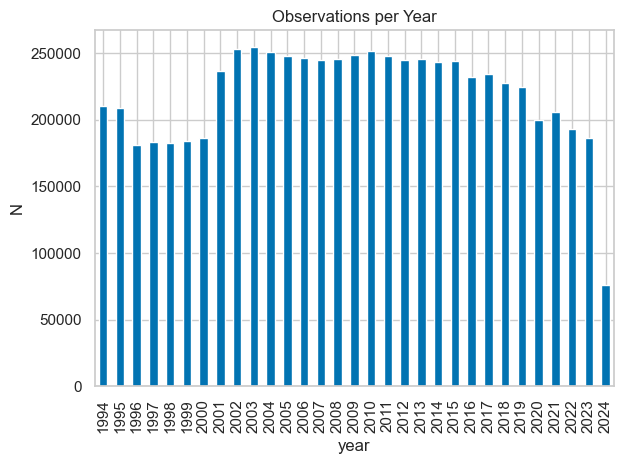

In [5]:
df.groupby("year").size().plot(kind="bar", title="Observations per Year")
plt.ylabel("N")
plt.tight_layout()
plt.show()



## Numeric Variable 
- Check income variables for top-coding and missing values by column year


In [6]:
print(df[["inctot", "incss", "income", "wgt"]].describe())

df.groupby("year")[["inctot", "incss", "income"]].apply(
    lambda x: x.isna().mean())

          inctot      incss     income        wgt
count 3887584.00 3895618.00 3895618.00 6823494.00
mean    51141.78    3084.86   39115.01    2048.06
std     71629.55    7564.84   66244.13    1326.20
min         0.00       0.00       0.00       0.00
25%     13615.15       0.00       0.00    1049.01
50%     34063.68       0.00   21289.80    1879.47
75%     65687.13       0.00   56227.58    2902.56
max   3320566.83  102251.02 2363551.00   44423.83


,inctot,incss,income
year,,,
1994,0.49,0.48,0.48
1995,0.49,0.48,0.48
1996,0.48,0.48,0.48
1997,0.48,0.48,0.48
1998,0.48,0.48,0.48
1999,0.48,0.48,0.48
2000,0.48,0.48,0.48
2001,0.37,0.36,0.36
2002,0.41,0.41,0.41




The missingness distribution by year between income variables are the same. The fact that missingness is identical across all three income variables across years suggests these are all coming from the ASEC supplement together. So missingness is structural — non-March rows have all three missing simultaneously. 

- 'wgt' is person-level weight from the CPS? 



In [7]:
# wgt diagnostics to determine whether it's ASEC march data or monthly
df.groupby(df["income"].notna())["wgt"].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
False,2927876.00,2385.32,1362.99,0.00,1276.40,2393.68,3287.81,20914.78
True,3895618.00,1794.58,1238.83,0.00,928.75,1621.30,2390.21,44423.83




**Note:** since wgt is evenly distributed across income missing and present rows, we can infer it's from monthly data. also known as 'WTFINL'. 

## Telework Variable Availability



In [8]:
# These should only be populated from ~2020 onward
telework_cols = ["covid_telework", "covid_unemployed", "covid_paid",
                 "telework_now", "telework_before", "telework_difference"]
for col in telework_cols:
    print(f"\n {col} by year ")
    print(df.groupby("year")[col].apply(lambda x: (x.notna() & (x != "NIU")).mean()))


 covid_telework by year 
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001   0.00
2002   0.00
2003   0.00
2004   0.00
2005   0.00
2006   0.00
2007   0.00
2008   0.00
2009   0.00
2010   0.00
2011   0.00
2012   0.00
2013   0.00
2014   0.00
2015   0.00
2016   0.00
2017   0.00
2018   0.00
2019   0.00
2020   0.00
2021   0.23
2022   0.24
2023   0.00
2024   0.00
Name: covid_telework, dtype: float64

 covid_unemployed by year 
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001   0.00
2002   0.00
2003   0.00
2004   0.00
2005   0.00
2006   0.00
2007   0.00
2008   0.00
2009   0.00
2010   0.00
2011   0.00
2012   0.00
2013   0.00
2014   0.00
2015   0.00
2016   0.00
2017   0.00
2018   0.00
2019   0.00
2020   0.00
2021   0.41
2022   0.41
2023   0.00
2024   0.00
Name: covid_unemployed, dtype: float64

 covid_paid by year 
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001 

## Flags & Data Cleaning

Resolved coding decisions:
- Survey weight: basic monthly CPS (`WTFINL`-equivalent), confirmed via `wgt` distribution across income-missing rows.
- `lfp`, `employed`, `self_employed`: binarized at point of use against canonical labels.
- `age`: stored as binned strings (`< 25`, `25-34`, ..., `75+`); no numeric coercion needed.
- Income variables (`inctot`, `incss`, `income`): structurally missing for non-March rows; no imputation.


In [9]:
# color blind friendly theme for all plots
sns.set_theme(style='whitegrid', palette='colorblind')

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




#### Helper function 



In [10]:
# helper function for applying weights and weighted means
def weighted_mean(data, value_col, weight_col):
    valid = data[[value_col, weight_col]].dropna()

    if valid.empty:
        return np.nan

    return np.average(valid[value_col], weights=valid[weight_col])

def wmean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




#### Subset and group by year 


In [11]:
df_women = df.loc[df['sex'] == 'Female'].copy()
df_women['lfp_bin'] = (df_women['lfp'] == 'In labor force').astype(int)

# weight LFP rate by year
lfp_by_year = (
    df_women.groupby('year')
    .apply(lambda g: wmean(g['lfp_bin'], g['wgt']))
    .rename('lfp_rate')
)



Note: LFP-missing observations constitutes <1% of the female sample; results are insensitive to these.

#### Plotting



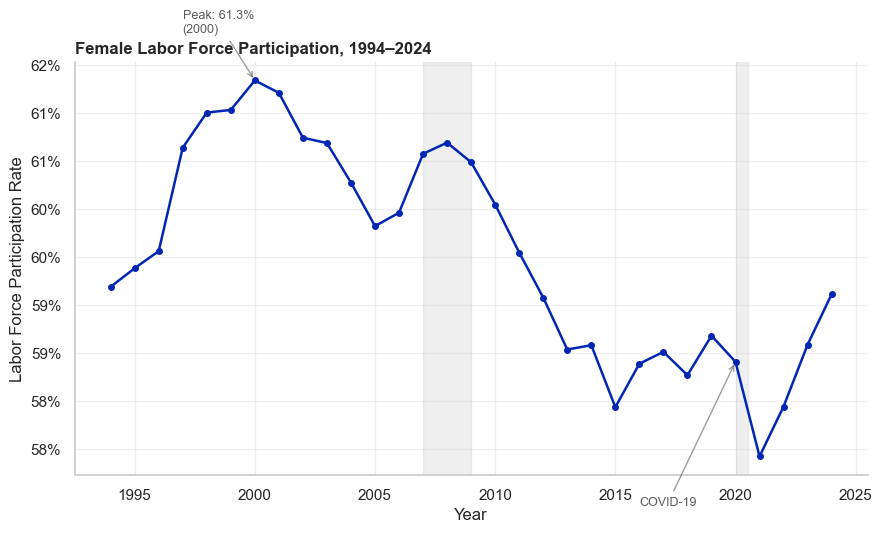

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(lfp_by_year.index, lfp_by_year.values,
        marker='o', markersize=4, linewidth=1.8, color=PAL['primary'])

peak_year = lfp_by_year.idxmax()
peak_val = lfp_by_year.max()
ax.annotate(f'Peak: {peak_val:.1%}\n({peak_year})',
            xy=(peak_year, peak_val),
            xytext=(peak_year - 3, peak_val + 0.005),
            fontsize=9, color=PAL['neutral'],
            arrowprops=dict(arrowstyle='->', color=PAL['neutral'], alpha=0.6))

covid_val = lfp_by_year.loc[2020]
ax.annotate('COVID-19',
            xy=(2020, covid_val),
            xytext=(2016, covid_val - 0.015),
            fontsize=9, color=PAL['neutral'],
            arrowprops=dict(arrowstyle='->', color=PAL['neutral'], alpha=0.6))

style_ax(ax,
         ylabel='Labor Force Participation Rate',
         title='Female Labor Force Participation, 1994–2024')
plt.tight_layout()
plt.show()



**Discussion:**


## Q2: Heterogeneity in LFP Changes (Women > 25)

Among women older than 25, which groups (race, age, income percentile, etc.) of
people had the biggest changes in labor force participation since 1994? Please provide at least three graphs and/or tables to support your answer.

Note: income quantile is partially endogenous to labor force status — non-participants tend to have lower individual income. I use income_quantiles (total income) rather than wageinc_quantiles (wage income) since the former is less mechanically tied to LFP, but causal interpretation should still be cautious.

### By Race



In [13]:
cols = ['year', 'lfp', 'wgt', 'race', 'age', 'income_quantiles',
        'education', 'college', 'self_employed', 'inctot', 'incss', 'income']
df_women = df.loc[df['sex'] == 'Female', cols].copy()
df_women['lfp_bin'] = (df_women['lfp'] == 'In labor force').astype(int)

df_w25 = df_women.loc[df_women['age'] != '< 25'].copy()

# helper for weighted LFP by year × group
def lfp_by_year_group(data, group_col):
    return (data.groupby(['year', group_col], observed=True)
                .apply(lambda g: wmean(g['lfp_bin'], g['wgt']))
                .unstack(group_col))



*Note:* I will exclude "Native American" and "Two or more" from the race plot due to small sample sizes, which produces noisy year-to-year estimates. These groups remain in the summary table for completeness.



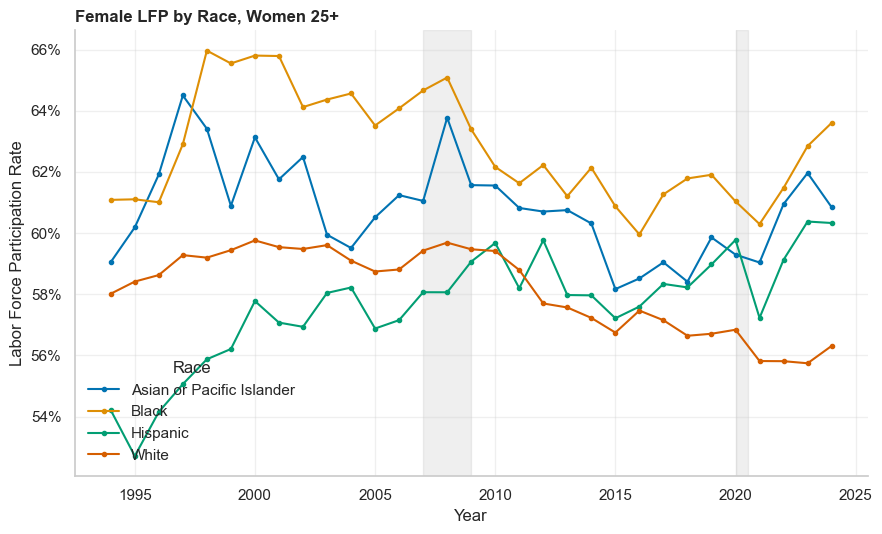

In [14]:
race_keep = ['White', 'Black', 'Hispanic', 'Asian or Pacific Islander']
lfp_race = lfp_by_year_group(
    df_w25.loc[df_w25['race'].isin(race_keep)],
    'race'
)

fig, ax = plt.subplots(figsize=(9, 5.5))
lfp_race.plot(ax=ax, marker='o', markersize=3, linewidth=1.5, color=PAL_CAT[:lfp_race.shape[1]])
ax.legend(title='Race', frameon=False, loc='lower left')
style_ax(ax, ylabel='Labor Force Participation Rate', title='Female LFP by Race, Women 25+')
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### By Age Group



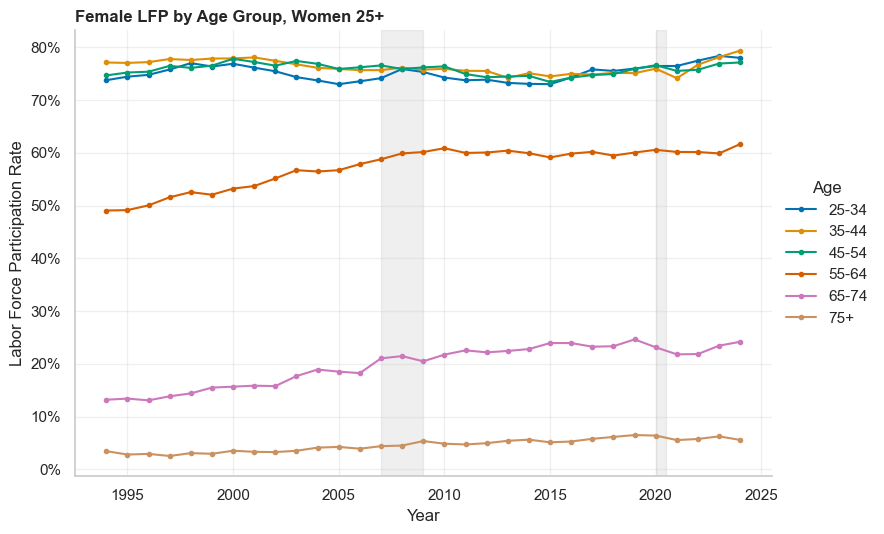

In [15]:
# Set categorical order so the legend is sorted by age
age_order = ['25-34', '35-44', '45-54', '55-64', '65-74', '75+']
df_w25['age'] = pd.Categorical(df_w25['age'], categories=age_order, ordered=True)

lfp_age = lfp_by_year_group(df_w25, 'age')

fig, ax = plt.subplots(figsize=(9, 5.5))
lfp_age.plot(ax=ax, marker='o', markersize=3, linewidth=1.5, color=PAL_CAT[:lfp_age.shape[1]])
ax.legend(title='Age', frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))
style_ax(ax, ylabel='Labor Force Participation Rate', title='Female LFP by Age Group, Women 25+')
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### By Income Quantile



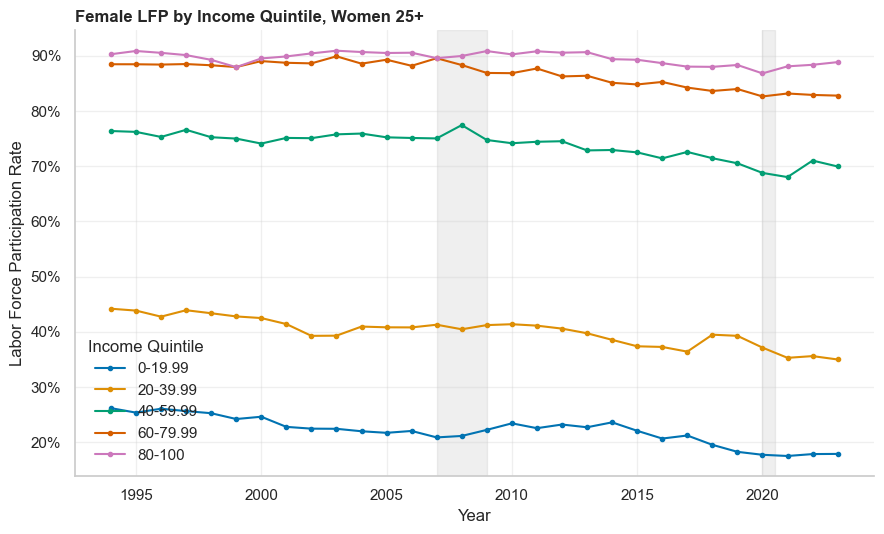

In [16]:
# Income quantiles only populated for ASEC rows
income_order = ['0-19.99', '20-39.99', '40-59.99', '60-79.99', '80-100']
df_w25_with_quantile = df_w25.dropna(subset=['income_quantiles']).copy()
df_w25_with_quantile['income_quantiles'] = pd.Categorical(
    df_w25_with_quantile['income_quantiles'], categories=income_order, ordered=True
)

lfp_inc = lfp_by_year_group(df_w25_with_quantile, 'income_quantiles')

fig, ax = plt.subplots(figsize=(9, 5.5))
lfp_inc.plot(ax=ax, marker='o', markersize=3, linewidth=1.5, color=PAL_CAT[:lfp_inc.shape[1]])
ax.legend(title='Income Quintile', frameon=False, loc='lower left')
style_ax(ax, ylabel='Labor Force Participation Rate', title='Female LFP by Income Quintile, Women 25+')
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


In [17]:
def endpoint_change(series, start=(1994, 1995, 1996), end=(2022, 2023)):
    # .reindex() is "safe" - it returns NaN for missing years instead of crashing
    start_vals = series.reindex(list(start))
    end_vals = series.reindex(list(end))
    
    start_mean = start_vals.mean()
    end_mean = end_vals.mean()
    
    return pd.Series({
        '1994-96': start_mean,
        '2022-23': end_mean,
        'Change (pp)': (end_mean - start_mean) * 100
    })

# The rest of your logic remains the same
summary = pd.concat([
    lfp_race.apply(endpoint_change).T.assign(Dimension='Race'),
    lfp_age.apply(endpoint_change).T.assign(Dimension='Age'),
    lfp_inc.apply(endpoint_change).T.assign(Dimension='Income Quintile'),
]).reset_index().rename(columns={'index': 'Group'})

summary = summary[['Dimension', 'Group', '1994-96', '2022-23', 'Change (pp)']]
display(summary)

,Dimension,Group,1994-96,2022-23,Change (pp)
0,Race,Asian or Pacific Islander,0.60,0.61,1.07
1,Race,Black,0.61,0.62,1.10
2,Race,Hispanic,0.54,0.60,6.06
3,Race,White,0.58,0.56,-2.58
4,Age,25-34,0.74,0.78,3.60
5,Age,35-44,0.77,0.77,0.31
6,Age,45-54,0.75,0.76,1.25
7,Age,55-64,0.49,0.60,10.61
8,Age,65-74,0.13,0.23,9.42
9,Age,75+,0.03,0.06,2.95



**Discussion:**

*[Which groups changed most? Is the story about convergence (gaps closing)
or divergence? Any group that bucks the overall trend?]*

Race has the largest heterogeneity, of the four categories included, white female trends down slightly in LFP, where other groups seems to converge after the great recession. Since the covid-19 pandemic is still a relatively recent shock, I want to caution against over-extrapolating the pattern but it seems to be fit the same narrative. 

## Q3: Trends in Wages, Social Insurance, and Education (Women > 25)
Use the data to examine trends among women older than 25 for each of the following factors from 1994 to 2024. 
### (a) Wage and Salary Income

Note: INCTOT, INCWAGE reflect the dollar value at the time the survey was taken, not adjusted for inflation.



In [18]:
# CPI-U deflator, 2024 base — VERIFY against BLS before final submission
cpi = {
    1994: 39.4, 1995: 40.5, 1996: 41.7, 1997: 42.6, 1998: 43.3,
    1999: 44.3, 2000: 45.7, 2001: 47.0, 2002: 47.8, 2003: 48.8,
    2004: 50.1, 2005: 51.8, 2006: 53.5, 2007: 55.0, 2008: 57.1,
    2009: 56.9, 2010: 57.8, 2011: 59.7, 2012: 60.9, 2013: 61.8,
    2014: 62.8, 2015: 62.9, 2016: 63.7, 2017: 65.0, 2018: 66.6,
    2019: 67.8, 2020: 68.7, 2021: 71.9, 2022: 77.7, 2023: 80.9,
    2024: 83.5
}
deflator = pd.Series({y: cpi[2024]/v for y, v in cpi.items()})

# Apply to ASEC subsample (income variables only populated in ASEC)
df_w25_inc = df_w25.dropna(subset=['income']).copy()
df_w25_inc['income_real']  = df_w25_inc['income']  * df_w25_inc['year'].map(deflator)
df_w25_inc['incss_real']   = df_w25_inc['incss']   * df_w25_inc['year'].map(deflator)

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


In [19]:
# quick sanity check 
df[['year']].describe()
df_w25.loc[df_w25['inctot'].notna(), ['inctot', 'incss', 'income']].head(20)

# np.average doesn't have a weighted-median equivalent
def wmedian(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    v, w = values[mask].values, weights[mask].values
    order = np.argsort(v)
    v, w = v[order], w[order]
    cum = np.cumsum(w)
    return v[np.searchsorted(cum, cum[-1] / 2)]

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


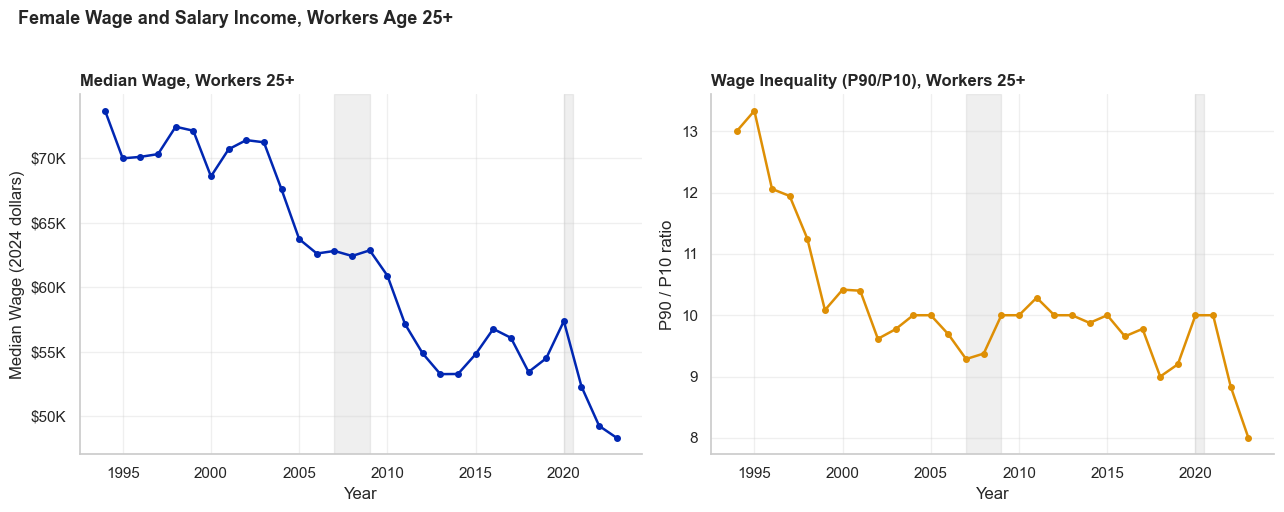

In [20]:
# Restrict to women with positive wage income (workers)
df_w25_workers = df_w25_inc.loc[df_w25_inc['income'] > 0].copy()

wage_by_year = (df_w25_workers.groupby('year')
                .apply(lambda g: wmedian(g['income_real'], g['wgt']))
                .rename('median_wage_real'))

# Weighted P10 / P90 helpers — extend wmedian
def wquantile(values, weights, q):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    v, w = values[mask].values, weights[mask].values
    order = np.argsort(v)
    v, w = v[order], w[order]
    cum = np.cumsum(w)
    return v[np.searchsorted(cum, cum[-1] * q)]

p_by_year = (df_w25_workers.groupby('year')
             .apply(lambda g: pd.Series({
                 'p10': wquantile(g['income_real'], g['wgt'], 0.10),
                 'p90': wquantile(g['income_real'], g['wgt'], 0.90),
             })))
p_by_year['p90_p10'] = p_by_year['p90'] / p_by_year['p10']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(wage_by_year.index, wage_by_year.values,
             marker='o', markersize=4, linewidth=1.8, color=PAL['primary'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
style_ax(axes[0], ylabel='Median Wage (2024 dollars)',
         title='Median Wage, Workers 25+', percent=False)

axes[1].plot(p_by_year.index, p_by_year['p90_p10'],
             marker='o', markersize=4, linewidth=1.8, color=PAL['accent'])
style_ax(axes[1], ylabel='P90 / P10 ratio',
         title='Wage Inequality (P90/P10), Workers 25+', percent=False)

fig.suptitle('Female Wage and Salary Income, Workers Age 25+',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.show()

Note: I report median wage conditional on positive earnings (workers only) so the trend isolates earnings dynamics from changes in labor force composition. The right panel adds the P90/P10 ratio to capture distributional widening.

### (b) Social Insurance Income

Note: I use `incss`, which captures Social Security income. Broader social insurance categories (SSI, UI, transfers) are not separately available in this extract.



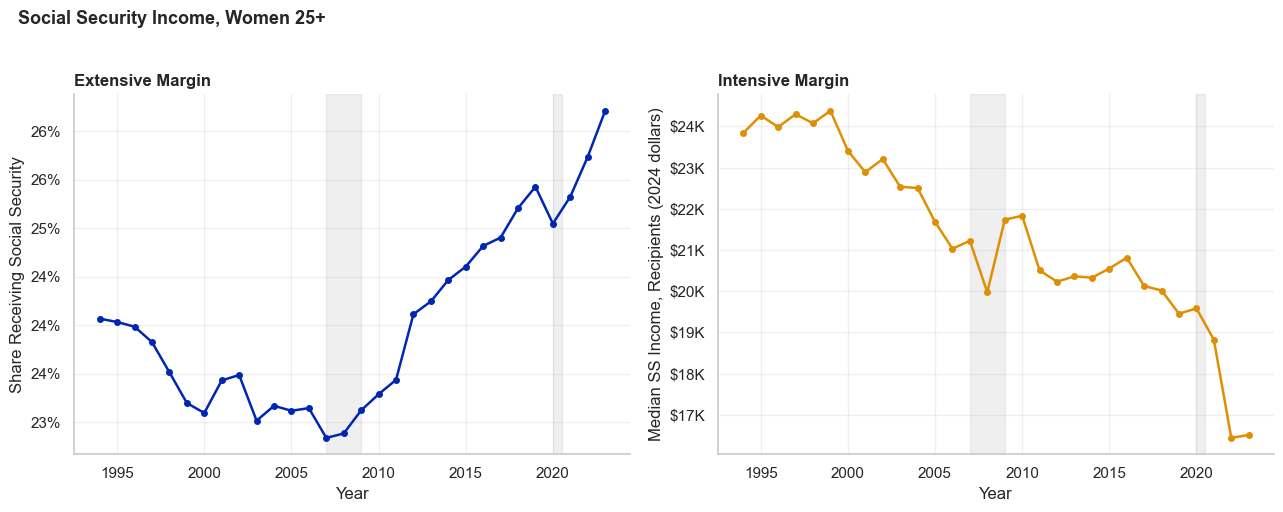

In [21]:
# Extensive margin: share with any SS income > 0
df_w25_inc['has_ss'] = (df_w25_inc['incss'] > 0).astype(int)
ss_share = (df_w25_inc.groupby('year')
            .apply(lambda g: wmean(g['has_ss'], g['wgt']))
            .rename('share_with_ss'))

# Intensive margin: median SS income among recipients (real)
ss_recipients = df_w25_inc.loc[df_w25_inc['incss'] > 0]
ss_median = (ss_recipients.groupby('year')
             .apply(lambda g: wmedian(g['incss_real'], g['wgt']))
             .rename('median_ss_real'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ss_share.index, ss_share.values,
             marker='o', markersize=4, linewidth=1.8, color=PAL['primary'])
style_ax(axes[0], ylabel='Share Receiving Social Security',
         title='Extensive Margin')

axes[1].plot(ss_median.index, ss_median.values,
             marker='o', markersize=4, linewidth=1.8, color=PAL['accent'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
style_ax(axes[1], ylabel='Median SS Income, Recipients (2024 dollars)',
         title='Intensive Margin', percent=False)

fig.suptitle('Social Security Income, Women 25+', fontsize=13, fontweight='bold',
             x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### (c) Education Attainment



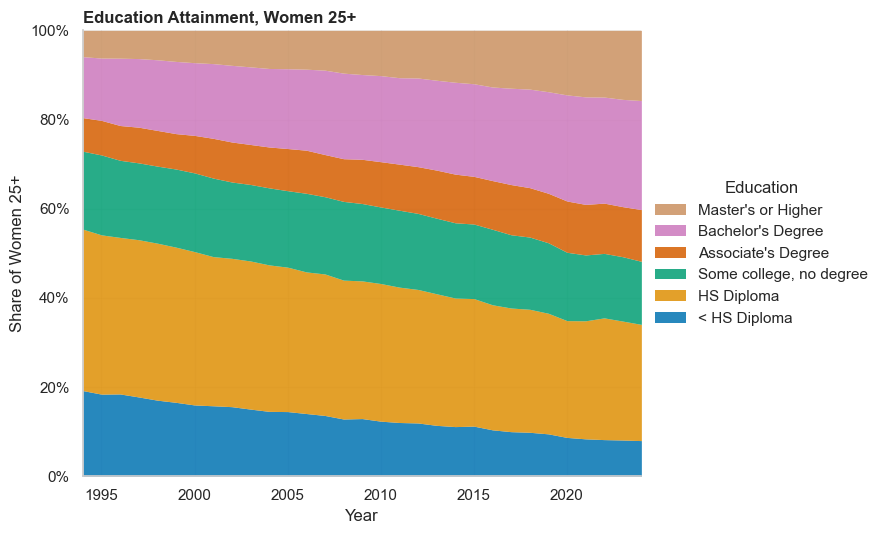

In [22]:
edu_order = ["< HS Diploma", "HS Diploma", "Some college, no degree",
             "Associate's Degree", "Bachelor's Degree", "Master's or Higher"]

df_w25['education'] = pd.Categorical(df_w25['education'],
                                     categories=edu_order, ordered=True)

def edu_share_by_year(data):
    out = (data.groupby(['year', 'education'], observed=True)
              .apply(lambda g: g['wgt'].sum())
              .unstack('education', fill_value=0))
    return out.div(out.sum(axis=1), axis=0)

edu_shares = edu_share_by_year(df_w25)

fig, ax = plt.subplots(figsize=(9, 5.5))
edu_shares.plot.area(ax=ax, alpha=0.85, linewidth=0, color=PAL_CAT[:edu_shares.shape[1]])
ax.set_ylim(0, 1)
ax.set_xlim(edu_shares.index.min(), edu_shares.index.max())
ax.legend(title='Education', frameon=False, loc='center left',
          bbox_to_anchor=(1, 0.5), reverse=True)
style_ax(ax, ylabel='Share of Women 25+', title='Education Attainment, Women 25+',
         recessions=False)
plt.tight_layout()
plt.show()



**Discussion:**

Based on these trends, what factors could be driving the patterns you found in Questions 1 and 2?

Discussion: The pattern to highlight here is how female wage and income have consistently been trending down after the great recession, bigger drops tend to happen after major systematic shocks. I decomposed total social income change to the following: extensive margin increase reflect the growing number of women near retirement age or retired, where decreasing intensive margin imply the median amount is decreasing. 
In terms of education amongst women 25+, HS diploma trends down slightly, which can be explained by the increase in those with Bachelor's degree and up. 
Extensive Margin: total share of employement taken into account.
Intensive Margin: Only counts those receiving social security. 

## Q4: Steepest Year-over-Year Increase in Female LFP

Between 1994 and 2024, which year had the steepest increase in female labor force participation relative to the previous year? What factors do you think are driving this pattern? Support your answers by using the data, referencing major events that happened around this time period, and/or citing previous studies.



In [23]:
yoy_change = lfp_by_year.diff()
peak_year = yoy_change.idxmax()
peak_change = yoy_change.max()

print(f"Steepest YoY increase: {peak_year}")
print(f"Change: {peak_change*100:.2f} percentage points")
print(f"LFP {peak_year-1}: {lfp_by_year[peak_year-1]:.1%}")
print(f"LFP {peak_year}: {lfp_by_year[peak_year]:.1%}")

Steepest YoY increase: 1997
Change: 1.08 percentage points
LFP 1996: 59.6%
LFP 1997: 60.6%


**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


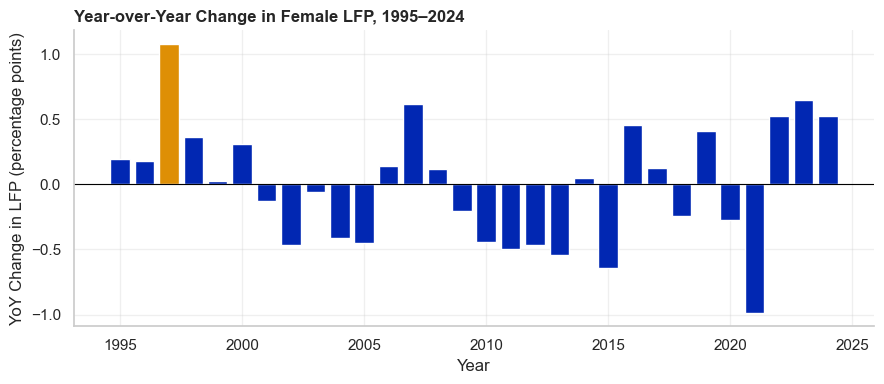

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = [PAL['accent'] if y == peak_year else PAL['primary'] for y in yoy_change.index]
ax.bar(yoy_change.index, yoy_change.values * 100, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
style_ax(ax, ylabel='YoY Change in LFP (percentage points)',
         title='Year-over-Year Change in Female LFP, 1995–2024',
         percent=False, recessions=False)
plt.tight_layout()
plt.show()

**Discussion:** The data point to 1997 as the steepest year-over-year increase in female LFP, +1.08 pp. Two policy currents likely drove this jump: (1) the 1996 Personal Responsibility and Work Opportunity Reconciliation Act (PRWORA) replaced AFDC with TANF and added work requirements for single mothers, and (2) the 1993 EITC expansion phased in through 1996, sharply raising the return to work for low-income women. Eissa and Liebman (1996, *QJE*) identify large LFP responses to EITC expansions among single mothers; Meyer and Rosenbaum (2001) and Blank (2002, *JEL*) attribute the bulk of the late-1990s LFP rise among single mothers to the joint effect of welfare reform and the EITC. Caveat: 1996-97 was also late-cycle expansion peak, so the policy and business-cycle effects are bundled; the figure cannot separate them.

## Q5: LFP by College Education

How has labor force participation for college-educated and not college-educated women evolved since 1994? Please provide graphs and/or tables to support your answer.



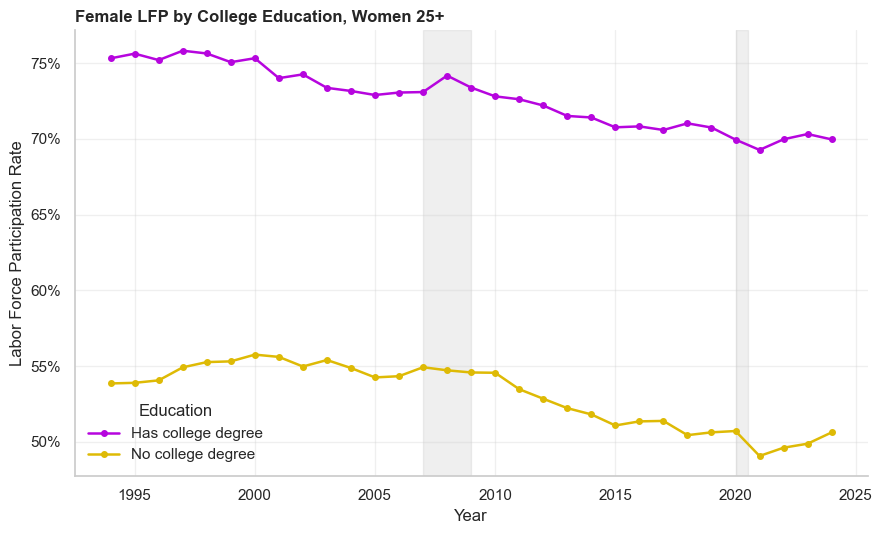

,1994-96,2022-23,Change (pp)
college,,,
Has college degree,0.75,0.70,-5.24
No college degree,0.54,0.50,-4.19


In [25]:
lfp_college = lfp_by_year_group(df_w25, 'college')

# Anchor colors so college=highlight, non-college=control regardless of column order
college_palette = {col: (PAL['highlight'] if 'Has' in col else PAL['control'])
                   for col in lfp_college.columns}

fig, ax = plt.subplots(figsize=(9, 5.5))
for col in lfp_college.columns:
    ax.plot(lfp_college.index, lfp_college[col],
            marker='o', markersize=4, linewidth=1.8,
            color=college_palette[col], label=col)
ax.legend(title='Education', frameon=False, loc='lower left')
style_ax(ax, ylabel='Labor Force Participation Rate',
         title='Female LFP by College Education, Women 25+')
plt.tight_layout()
plt.show()

endpoint_change_table = lfp_college.apply(endpoint_change).T
endpoint_change_table



I only included those older than 25, becaue 22 is the normal age of college graduates and age of first job post-college can depend on labor market conditions and business cycles. 
As shown on the graph, female labor force participation for those over the age of 25 seems to be decreasing over all, notably after the great recession and covid-19 pandemic. However, labor force particpation rate of college degree holders is significantly higher than those without. 
College-educated women also suffered a smaller LFP drop in 2020. 


## Q6: Alternative LFP Measure (Excluding Self-Employed)

Create an alternative measure of labor force participation that excludes individuals from the labor force if they are self-employed in their main job (lfp = 0 if self-employed in main job). Using the new measure, describe how labor force participation for college-educated and not college-educated women has evolved since 1994. Please provide graphs and/or tables to support your answer.

note: Unemployed labor force participants (lfp = In labor force, self_employed = NaN) are coded as lfp_alt = 1 since the self-employment question applies only to current jobs.



In [26]:
# verify self employment flag for female subset
df_w25['self_employed'].value_counts(dropna=False)

self_employed
Not self-employed    1655288
NaN                  1356372
Self-employed         172615
Name: count, dtype: int64

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


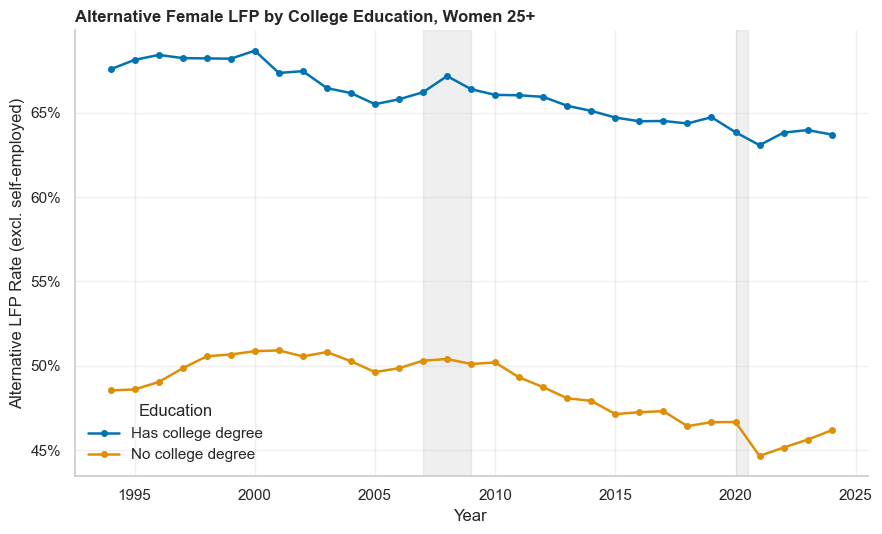

In [27]:
df_w25['lfp_alt'] = np.where(
    (df_w25['lfp'] == 'In labor force') & (df_w25['self_employed'] != 'Self-employed'),
    1, 0
)

lfp_alt_college = (df_w25.groupby(['year', 'college'], observed=True)
                   .apply(lambda g: wmean(g['lfp_alt'], g['wgt']))
                   .unstack('college'))

fig, ax = plt.subplots(figsize=(9, 5.5))
lfp_alt_college.plot(ax=ax, marker='o', markersize=4, linewidth=1.8)

ax.axvspan(2007, 2009, alpha=0.12, color='gray', zorder=0)
ax.axvspan(2020, 2020.5, alpha=0.12, color='gray', zorder=0)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Year')
ax.set_ylabel('Alternative LFP Rate (excl. self-employed)')
ax.set_title('Alternative Female LFP by College Education, Women 25+',
             loc='left', fontsize=12, fontweight='bold')
ax.legend(title='Education', frameon=False, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


In [28]:
se_rate = (df_w25.loc[df_w25['lfp_bin'] == 1]
           .groupby(['year', 'college'], observed=True)
           .apply(lambda g: wmean((g['self_employed'] == 'Self-employed').astype(int), g['wgt']))
           .unstack('college'))
print(se_rate.loc[[1994, 2024]])
print("\nMean self-employment rate by college status:")
print(se_rate.mean())

college  Has college degree  No college degree
year                                          
1994                   0.10               0.10
2024                   0.09               0.09

Mean self-employment rate by college status:
college
Has college degree   0.09
No college degree    0.08
dtype: float64


## Q1: Outcomes by Telework Status (2023-2024)

Since the rise of telework in 2020, how have wages, employment, and labor force participation changed for women who had telework and women who did not? Please provide at least three graphs and/or tables to support your answer.

**Approach:** I use `telework_now` (= 1 if the respondent teleworked in the past week). Coverage caveat: BLS introduced this question in October 2022, so the basic monthly CPS only carries it for **2023-2024** in this extract (84K non-null observations). The pre-pandemic counterfactual is therefore not directly observable; comparisons are between concurrent telework and non-telework women, which mixes treatment and selection.



In [29]:
for col in ['telework_now', 'covid_telework', 'telework_before']:
    print(f"\n{col} by year:")
    print(df.groupby('year')[col].apply(lambda x: x.notna().mean()).round(3))


telework_now by year:
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001   0.00
2002   0.00
2003   0.00
2004   0.00
2005   0.00
2006   0.00
2007   0.00
2008   0.00
2009   0.00
2010   0.00
2011   0.00
2012   0.00
2013   0.00
2014   0.00
2015   0.00
2016   0.00
2017   0.00
2018   0.00
2019   0.00
2020   0.00
2021   0.00
2022   0.00
2023   0.22
2024   0.56
Name: telework_now, dtype: float64

covid_telework by year:
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001   0.00
2002   0.00
2003   0.00
2004   0.00
2005   0.00
2006   0.00
2007   0.00
2008   0.00
2009   0.00
2010   0.00
2011   0.00
2012   0.00
2013   0.00
2014   0.00
2015   0.00
2016   0.00
2017   0.00
2018   0.00
2019   0.00
2020   0.00
2021   0.23
2022   0.24
2023   0.00
2024   0.00
Name: covid_telework, dtype: float64

telework_before by year:
year
1994   0.00
1995   0.00
1996   0.00
1997   0.00
1998   0.00
1999   0.00
2000   0.00
2001   0.00

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


In [30]:
df_women = df[df['sex'] == 'Female'].copy()

# Subset: women in years where telework is observed
df_tw = df_women.loc[df_women['telework_now'].notna()].copy()
df_tw['teleworked'] = (df_tw['telework_now'] == 'Had telework in the past week').astype(int)
df_tw['employed_bin'] = (df_tw['employed'] == 'Employed').astype(int)
df_tw['lfp_bin'] = (df_tw['lfp'] == 'In labor force').astype(int)

print(df_tw.groupby('year')['teleworked'].agg(['mean', 'size']))

      mean   size
year             
2023  0.19  23479
2024  0.22  23968


**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### Wages by Telework Status





Note: Wage comparisons by telework status are not feasible in this extract: telework variables (telework_now) are populated in 2023–2024 basic monthly CPS, while income variables come from the ASEC supplement, with no overlapping observations. The employment and LFP comparisons below use the basic monthly sample where telework is observed. 

### Employment by Telework Status



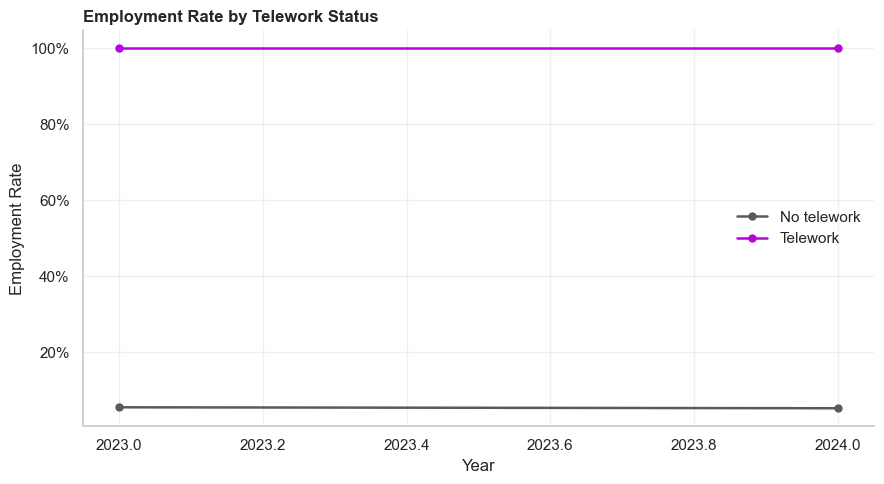

In [31]:
emp_tw = (df_tw.groupby(['year', 'teleworked'])
          .apply(lambda g: wmean(g['employed_bin'], g['wgt']))
          .unstack('teleworked')
          .rename(columns={0: 'No telework', 1: 'Telework'}))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(emp_tw.index, emp_tw['No telework'], marker='o', markersize=5,
        linewidth=1.8, color=PAL['neutral'], label='No telework')
ax.plot(emp_tw.index, emp_tw['Telework'], marker='o', markersize=5,
        linewidth=1.8, color=PAL['highlight'], label='Telework')
ax.legend(frameon=False)
style_ax(ax, ylabel='Employment Rate', title='Employment Rate by Telework Status',
         recessions=False)
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### LFP by Telework Status



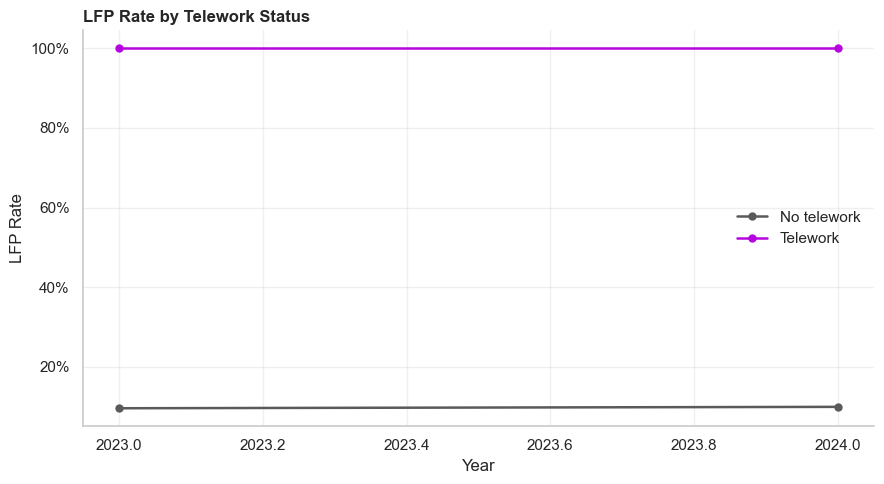

In [32]:
lfp_tw = (df_tw.groupby(['year', 'teleworked'])
          .apply(lambda g: wmean(g['lfp_bin'], g['wgt']))
          .unstack('teleworked')
          .rename(columns={0: 'No telework', 1: 'Telework'}))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lfp_tw.index, lfp_tw['No telework'], marker='o', markersize=5,
        linewidth=1.8, color=PAL['neutral'], label='No telework')
ax.plot(lfp_tw.index, lfp_tw['Telework'], marker='o', markersize=5,
        linewidth=1.8, color=PAL['highlight'], label='Telework')
ax.legend(frameon=False)
style_ax(ax, ylabel='LFP Rate', title='LFP Rate by Telework Status',
         recessions=False)
plt.tight_layout()
plt.show()



**Discussion:** Teleworkers have higher LFP (selection into telework-capable jobs, since those are likely all office-jobs). Teleworkers have higher employment and LFP rates than non-teleworkers in 2023–2024. These gaps are descriptive: telework availability is correlated with occupation, education, and industry, so we are comparing groups that differ on many observables. The data are consistent with telework being a privilege of higher-attachment, higher-skill workers rather than a treatment with a clean causal effect on labor market outcomes.


## Q2: Who Teleworked During the Pandemic? (Women > 25, 2021)

For which groups of women older than 25 was telework due to the pandemic most
common in 2021? Based on these patterns, what can you infer about the relationship between economic well-being and the ability to telework between 2021? Please provide at least three graphs and/or tables to support your answer.

Note from BLS website: "BLS added new questions to the Current Population Survey (CPS) starting in October 2022 that focus on telework or work at home for pay."



In [33]:
# Subset: women 25+, 2021, with covid_telework observed
df_2021 = df.loc[
    (df['sex'] == 'Female') 
    & (df['age'] != '< 25') 
    & (df['year'] == 2021) 
    & (df['covid_telework'].notna())
].copy()
df_2021['tw_pandemic'] = (df_2021['covid_telework'] == 
                          'Telework from 2021-2022 due to COVID').astype(int)
print(f"N: {len(df_2021)}")

N: 20929


**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 




### Telework by Race



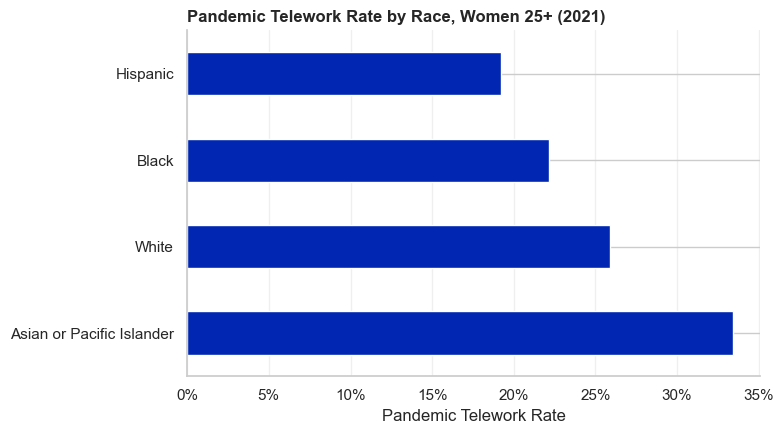

In [34]:
race_keep = ['White', 'Black', 'Hispanic', 'Asian or Pacific Islander']
tw_race = (df_2021.loc[df_2021['race'].isin(race_keep)]
           .groupby('race', observed=True)
           .apply(lambda g: wmean(g['tw_pandemic'], g['wgt']))
           .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
tw_race.plot(kind='barh', ax=ax, color=PAL['primary'])
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Pandemic Telework Rate')
ax.set_ylabel('')
ax.set_title('Pandemic Telework Rate by Race, Women 25+ (2021)',
             loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 





### Telework by Education



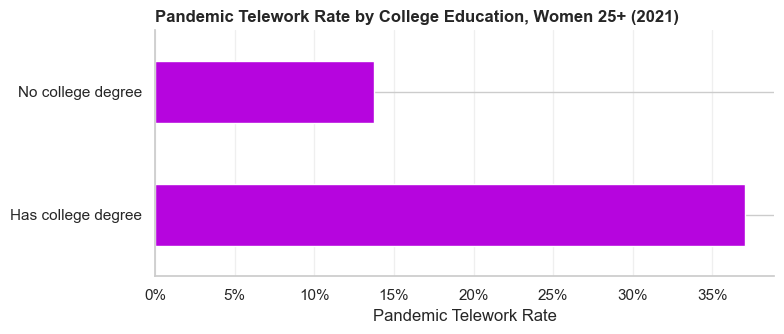

In [35]:
tw_college = (df_2021.groupby('college', observed=True)
              .apply(lambda g: wmean(g['tw_pandemic'], g['wgt']))
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
tw_college.plot(kind='barh', ax=ax, color=PAL['highlight'])
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Pandemic Telework Rate')
ax.set_ylabel('')
ax.set_title('Pandemic Telework Rate by College Education, Women 25+ (2021)',
             loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



**Discussion:**

## Q3: Counterfactual — What If Telework Wasn't an Option?

Predict what trends in wages, employment, and labor force participation for college-educated women from 2020 to 2024 would have looked like if telework was not an option. What does this tell you about the economic impacts of telework during the COVID-19 pandemic? Please support your answer with graphs and/or tables. 

**Approach:** Y = labor market outcome, T = telework, use non-college educated women as counterfactual in 2x2 DiD and 2010-2019 as a pre-treatment period. 
$$τ^=(Ycollege, post​−Ycollege, pre​)−(Ynon, post​−Ynon, pre​)$$

Assumption: Paraellel Trend, need to inspect visually at least. 



In [36]:
cols_needed = ['year', 'sex', 'age', 'lfp', 'employed', 'college', 
               'self_employed', 'race', 'wgt', 'covid_telework', 'telework_now']

df_women = df.loc[df['sex'] == 'Female', cols_needed].copy()
df_women['lfp_bin'] = (df_women['lfp'] == 'In labor force').astype(int)
df_women['employed_bin'] = (df_women['employed'] == 'Employed').astype(int)

df_w25 = df_women.loc[df_women['age'] != '< 25'].copy()

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


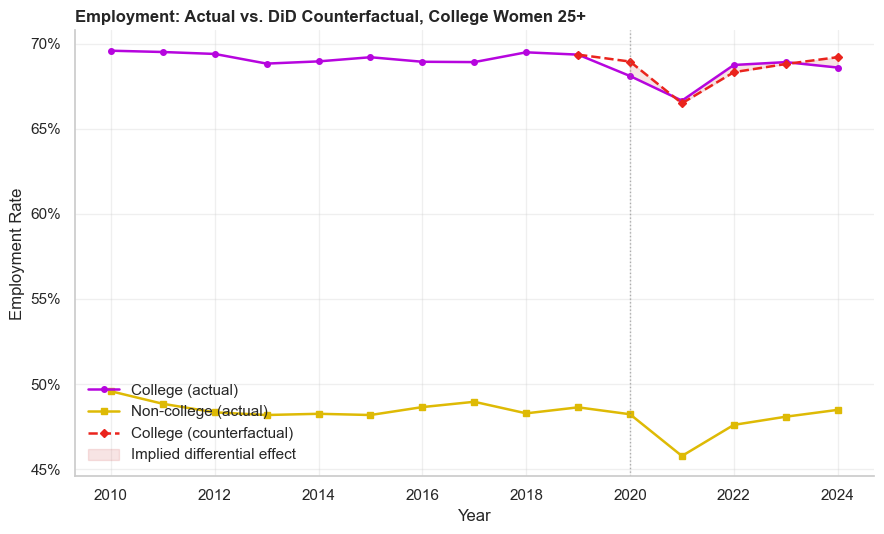

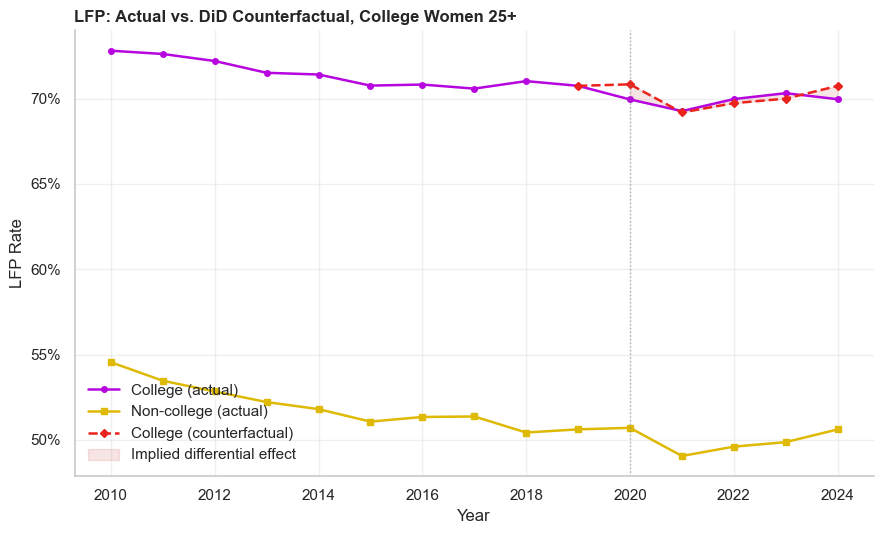

In [37]:
# Build employment series by year × college, women 25+
emp_college = (df_w25.groupby(['year', 'college'], observed=True)
               .apply(lambda g: wmean(g['employed_bin'], g['wgt']))
               .unstack('college'))

# Rebuild LFP series too if not in scope
lfp_college = (df_w25.groupby(['year', 'college'], observed=True)
               .apply(lambda g: wmean(g['lfp_bin'], g['wgt']))
               .unstack('college'))

def did_counterfactual(series_wide, treated_col, control_col, base_year=2019, 
                       post_start=2020, post_end=2024):
    """DiD counterfactual: apply control's post-base deviations to treated baseline."""
    treated_base = series_wide.loc[base_year, treated_col]
    control_base = series_wide.loc[base_year, control_col]
    post_years = range(post_start, post_end + 1)
    return pd.Series(
        {y: treated_base + (series_wide.loc[y, control_col] - control_base) 
         for y in post_years},
        name='counterfactual'
    )

cf_emp = did_counterfactual(emp_college, 'Has college degree', 'No college degree')
cf_lfp = did_counterfactual(lfp_college, 'Has college degree', 'No college degree')

def plot_did(series_wide, cf, ylabel, title, treated_col='Has college degree',
             control_col='No college degree'):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    # Actuals — both groups, full range
    full = series_wide.loc[2010:2024]
    ax.plot(full.index, full[treated_col], marker='o', markersize=4, 
            linewidth=1.8, color=PAL['highlight'], label='College (actual)')
    ax.plot(full.index, full[control_col], marker='s', markersize=4, 
            linewidth=1.8, color=PAL['control'], label='Non-college (actual)')
    
    # Counterfactual: anchor at 2019 then follow control deviations
    cf_full = pd.concat([pd.Series({2019: series_wide.loc[2019, treated_col]}), cf])
    ax.plot(cf_full.index, cf_full.values, marker='D', markersize=4, 
            linewidth=1.8, linestyle='--', color=PAL['cf'], 
            label='College (counterfactual)')
    
    # Shade the gap
    actual_post = series_wide.loc[2020:2024, treated_col]
    ax.fill_between(actual_post.index, actual_post.values, cf.values,
                    alpha=0.15, color=PAL['shade'], label='Implied differential effect')
    
    ax.axvline(2020, color='gray', linestyle=':', alpha=0.6, linewidth=1)
    
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.legend(frameon=False, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_did(emp_college, cf_emp, 'Employment Rate',
         'Employment: Actual vs. DiD Counterfactual, College Women 25+')

plot_did(lfp_college, cf_lfp, 'LFP Rate',
         'LFP: Actual vs. DiD Counterfactual, College Women 25+')

**Discussion:**

- *Pattern:* 
- *Mechanism:* 
- *Caveat:* 


In [38]:
def did_summary(series_wide, cf, treated_col='Has college degree'):
    actual = series_wide.loc[2020:2024, treated_col]
    return pd.DataFrame({
        'Actual': actual,
        'Counterfactual': cf,
        'Gap (pp)': (actual - cf) * 100
    })

print("Employment:")
print(did_summary(emp_college, cf_emp).round(3))
print("\nLFP:")
print(did_summary(lfp_college, cf_lfp).round(3))

Employment:
      Actual  Counterfactual  Gap (pp)
2020    0.68            0.69     -0.85
2021    0.67            0.67      0.16
2022    0.69            0.68      0.42
2023    0.69            0.69      0.11
2024    0.69            0.69     -0.61

LFP:
      Actual  Counterfactual  Gap (pp)
2020    0.70            0.71     -0.89
2021    0.69            0.69      0.08
2022    0.70            0.70      0.24
2023    0.70            0.70      0.32
2024    0.70            0.71     -0.78




**Discussion:** *Lead caveat first.* Parallel trends does not hold cleanly here: the pre-2020 series (figures above) shows non-college women's LFP falling while college women's stays roughly flat, so the DiD counterfactual extrapolates a downward path that the treated group never followed. With that caveat in mind:

1. **Direction and magnitude.** Estimated gaps are small (|Gap| < 1 pp) and switch sign year-to-year — in 2020 and 2024 college women fared *worse* than the counterfactual, in 2022-2023 *better*. The differential effect is not robustly signed.

2. **Why "non-college" is a poor control.** Non-college women bore the brunt of the COVID service-sector job losses; using their post-2020 trajectory as the counterfactual produces a deflated benchmark that college women easily clear. The DiD identifies the *differential* effect of telework, not the level effect — so even if both groups benefited from telework, with non-college benefiting somewhat, DiD would estimate a small differential.

3. **Ceiling effects.** College-educated women's LFP/employment was already near 70% with limited downside before COVID. The pandemic's effect on this group likely fell on hours, wages, and informal labor — margins this binary measure cannot detect.

4. **What the data are consistent with.** The post-2020 college rebound exceeds the counterfactual in most years, which is consistent with telework softening the employment hit for college-educated women. But given the parallel-trends violation, this is suggestive — not a credible causal estimate. A cleaner design would use occupation-level telework feasibility (e.g. Dingel-Neiman 2020) interacted with COVID exposure.



---

## Data and Replication

- **Data**: `cps_women_lfp.csv` — 6,823,494 individual-level CPS observations, 1994-2024, 22 variables.
- **Income variables** (`inctot`, `incss`, `income`) populated only for ASEC March-supplement rows (~57% of sample); basic monthly rows use `wgt` (= `WTFINL`-equivalent).
- **Telework variables** populated 2023-2024 (`telework_now`, `telework_before`) and 2021 only (`covid_*`); BLS introduced the new questions in October 2022.
- **CPI deflator**: CPI-U, 2024 base. Source: BLS Series CUUR0000SA0; verify against [bls.gov/cpi](https://www.bls.gov/cpi/) before final submission.
- **Software**: Python 3.14, pandas, numpy, matplotlib, seaborn, statsmodels, pyfixest. See `pyproject.toml`.
- **Reproduce**: open `analysis.ipynb` and `Run All`, or `jupyter nbconvert --execute --to notebook --inplace analysis.ipynb`.
